# The simulator and the recovery study

> Alderquist is a fictional direct to consumer home goods brand and its market is simulated with known truth. The email experiment is Kevin Hillstrom's public 2008 dataset, the purchase history is the UCI Online Retail II dataset, and the large uplift set is Criteo's public research release. No real company's spend and no real customer's identity appears here.

In this notebook I simulate the demonstration market, draw its true response curves, fit the repository's own mix model to it, keep one dead end from the build, and run a small version of the recovery study that the published figures come from.

Every number printed below comes from this notebook's run and says how many seeds it rests on. None of them is copied into a document. Where I show a published figure, I read it from `results/manifest.json` and print its provenance beside it. The notebook needs only the committed files under `data/sim` and `results`; it never opens `data/external`.

In [1]:
import json
import textwrap
import time

import matplotlib.pyplot as plt
import nbformat
import numpy as np
import polars as pl
from marginal_core.config import CHANNEL_LABELS, CHANNELS, POLICY
from marginal_core.formats import format_value
from marginal_core.manifest import Manifest
from marginal_core.paths import paths
from marginal_core.statements import contains_statement

ROOT = paths().root
NOTEBOOK = ROOT / "notebooks" / "01_simulator_and_recovery.ipynb"
# The statement in the first cell must match the one the code carries, word for word.
assert contains_statement(nbformat.read(NOTEBOOK, as_version=4).cells[0].source)

manifest = Manifest.load(paths().manifest)
SEED = manifest.seed  # the seed behind every published figure on the demonstration brand

# The site's palette in light mode. Channels take the categorical slots in their fixed order and
# slot eight is kept for comparators, as on the site.
PALETTE = json.loads((ROOT / "web" / "src" / "theme" / "palette.json").read_text())["light"]
INK, INK2, CONTROL, HAIRLINE, RAISED = (PALETTE[k] for k in ("ink", "ink2", "control", "hairline", "raised"))
CAT, SEQ = PALETTE["categorical"], PALETTE["sequential"]
COLOR = {channel: CAT[i] for i, channel in enumerate(CHANNELS)}
COMPARATOR = CAT[7]

plt.rcParams.update(
    {
        "figure.facecolor": RAISED,
        "axes.facecolor": RAISED,
        "savefig.facecolor": RAISED,
        "figure.dpi": 100,
        "axes.edgecolor": HAIRLINE,
        "axes.linewidth": 0.8,
        "axes.labelcolor": INK2,
        "axes.titlecolor": INK,
        "axes.titlesize": 10,
        "axes.titlelocation": "left",
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "axes.axisbelow": True,
        "grid.color": HAIRLINE,
        "grid.linewidth": 0.8,
        "xtick.color": HAIRLINE,
        "ytick.color": HAIRLINE,
        "xtick.labelcolor": INK2,
        "ytick.labelcolor": INK2,
        "text.color": INK,
        "text.parse_math": False,  # dollar signs in labels are dollars
        "font.size": 9,
        "legend.frameon": False,
        "legend.fontsize": 8.5,
        "lines.linewidth": 2,
        "lines.solid_capstyle": "round",
        "lines.solid_joinstyle": "round",
    }
)


def run(seeds, detail=""):
    """The label on every number this notebook computes."""
    return f"This notebook's run, {seeds} seed{'' if seeds == 1 else 's'}{detail}."


def published(key):
    """A published figure as the manifest formats it, with its provenance."""
    return f"{manifest.text(key)}  [{manifest.label(key)}]"


def show(columns, rows, note):
    """A small table as aligned text, the first column to the left and the rest to the right,
    with the line that says whose numbers these are."""
    cells = [[str(c) for c in columns], *[[str(v) for v in row] for row in rows]]
    widths = [max(len(row[i]) for row in cells) for i in range(len(columns))]

    def line(row):
        return "  ".join(v.ljust(w) if i == 0 else v.rjust(w) for i, (v, w) in enumerate(zip(row, widths)))

    print("\n".join([line(cells[0]), "  ".join("-" * w for w in widths), *map(line, cells[1:]), note]))


def finish(fig, title, note):
    """The title at the top left and the provenance line under the chart, wrapped to the figure's width."""
    fig.suptitle(title, x=0.01, ha="left", fontsize=11.5, color=INK)
    fig.text(0.01, -0.01, textwrap.fill(note, width=int(fig.get_figwidth() * 15)), ha="left", va="top", fontsize=8, color=INK2)
    plt.show()

## 1. What the simulator does, and why a mix model is graded on it first

The simulator writes down a market before any model sees it: forty geos, 156 weeks and seven paid channels. Sales in a geo and week are organic demand (season, trend, price, promotions, holidays and a competitor) plus what each channel adds. A channel's spend is carried over by geometric adstock and passed through a Hill saturation curve, and the carryover, the half saturation point, the slope and the ceiling are all known. Two switches make it hard the way real markets are hard. The channels' weekly spend moves together (rho), because brands plan their flights together. And display and retargeting spend follows last week's demand (feedback), because that is what retargeting does.

A mix model fit on a real brand always returns numbers, and nobody can say whether they are right, because nobody knows a real channel's true return. On the simulator the answer is written down first. So before a model gets near a budget, I ask it to find answers I planted, on many seeds and in the conditions where it should struggle. A model that cannot find them on a market built to its own assumptions has no business moving real money.

## 2. One demonstration market

`demonstration_spec(seed)` is the brand the published pages describe: spend planned with a target correlation of 0.6, and retargeting that follows demand. I simulate it with the seed the manifest records and check the result against the committed panel. The table is the truth the model will be graded on.

In [2]:
from marginal_sim import demonstration_spec, national_truth_table, response, simulate_market

spec = demonstration_spec(SEED)
geo, national, market = simulate_market(spec)
truth = national_truth_table(national, market)
TRUTH = {r["channel"]: r for r in truth.iter_rows(named=True)}

print(f"{spec.geos} geos, {spec.weeks} weeks, condition {spec.condition}.")
print("Identical to the committed data/sim/national.parquet:", national.equals(pl.read_parquet(paths().sim / "national.parquet")))
print()
show(
    ["Channel", "True return", "True marginal return", "Carryover", "Half life (weeks)", "Half saturation", "Slope", "Weekly spend now"],
    [
        [
            CHANNEL_LABELS[c],
            f"{TRUTH[c]['roas_true']:.2f}",
            f"{TRUTH[c]['marginal_return_true']:.2f}",
            f"{TRUTH[c]['carryover']:.2f}",
            f"{TRUTH[c]['half_life_weeks']:.1f}",
            format_value(TRUTH[c]["half_saturation"], "usd0"),
            f"{TRUTH[c]['slope']:.1f}",
            format_value(TRUTH[c]["weekly_spend_current"], "usd0"),
        ]
        for c in CHANNELS
    ],
    run(1, f" (seed {SEED}). The return and the spend are last year's: the last 52 weeks"),
)

40 geos, 156 weeks, condition rho 0.6, feedback on.
Identical to the committed data/sim/national.parquet: True

Channel                    True return  True marginal return  Carryover  Half life (weeks)  Half saturation  Slope  Weekly spend now
-------------------------  -----------  --------------------  ---------  -----------------  ---------------  -----  ----------------
Paid search                       3.15                  2.35       0.20                0.4         $117,000    1.6          $129,669
Paid social                       2.37                  2.33       0.35                0.7         $121,000    1.8          $110,747
Online video                      1.59                  1.43       0.65                1.6          $84,000    1.5           $63,969
Display and retargeting           1.22                  0.69       0.30                0.6          $49,000    2.2           $82,854
Email                             7.70                  4.06       0.15                0.4

The curves below are that truth drawn out: weekly incremental revenue at a steady weekly spend, from nothing to three times what each channel spends now. The dot is last year's average weekly spend. The slope at the dot is the marginal return, the number a budget should equalize across channels. Here it is below the average return for every channel: the last dollar earns less than the average dollar, which is why a budget is judged at the margin.

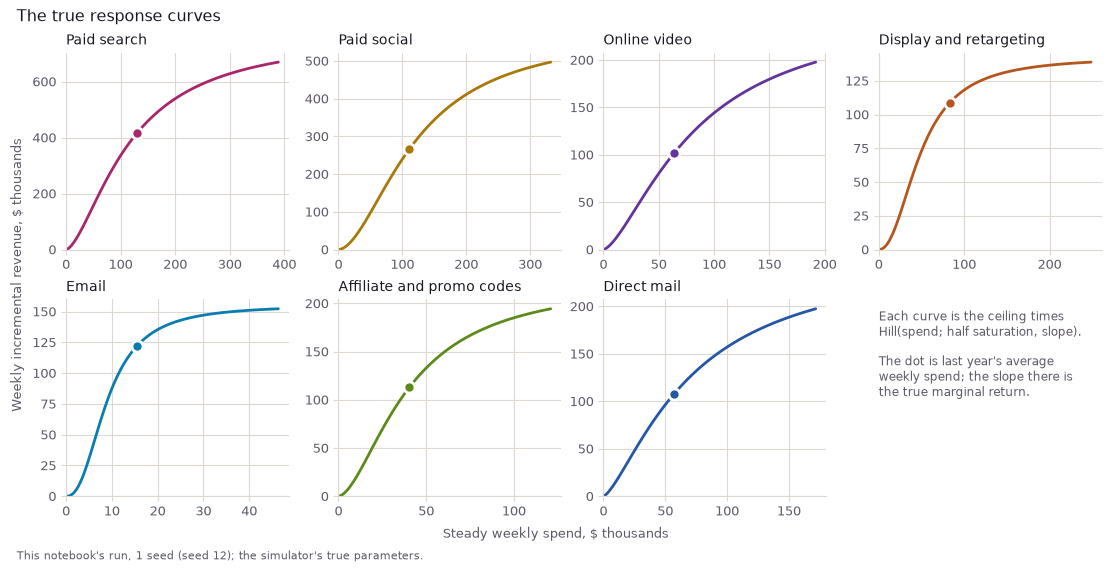

In [3]:
params = {p.channel: p for p in market.truth}
fig, axes = plt.subplots(2, 4, figsize=(11, 5.4), layout="constrained")
for ax, channel in zip(axes.flat, CHANNELS):
    now = TRUTH[channel]["weekly_spend_current"]
    grid = np.linspace(0.0, 3.0 * now, 121)
    ax.plot(grid / 1e3, response(params[channel], grid) / 1e3, color=COLOR[channel])
    at_now = float(response(params[channel], np.array([now]))[0])
    ax.plot(now / 1e3, at_now / 1e3, "o", ms=8, color=COLOR[channel], mec=RAISED, mew=2)
    ax.set_title(CHANNEL_LABELS[channel])
    ax.set_xlim(left=0)
    ax.set_ylim(bottom=0)
note = axes.flat[-1]
note.axis("off")
note.text(
    0.0, 0.95,
    "Each curve is the ceiling times\nHill(spend; half saturation, slope).\n\nThe dot is last year's average\nweekly spend; the slope there is\nthe true marginal return.",
    va="top", fontsize=8.5, color=INK2,
)
fig.supxlabel("Steady weekly spend, $ thousands", fontsize=9, color=INK2)
fig.supylabel("Weekly incremental revenue, $ thousands", fontsize=9, color=INK2)
finish(fig, "The true response curves", run(1, f" (seed {SEED}); the simulator's true parameters"))

Now the first switch. Below are three markets that differ only in rho, the target correlation of the channels' weekly spend shocks; feedback stays on, as on the demonstration brand. Each cell is the correlation between two channels' log weekly spend over the 156 weeks. Each market takes a fraction of a second to simulate.

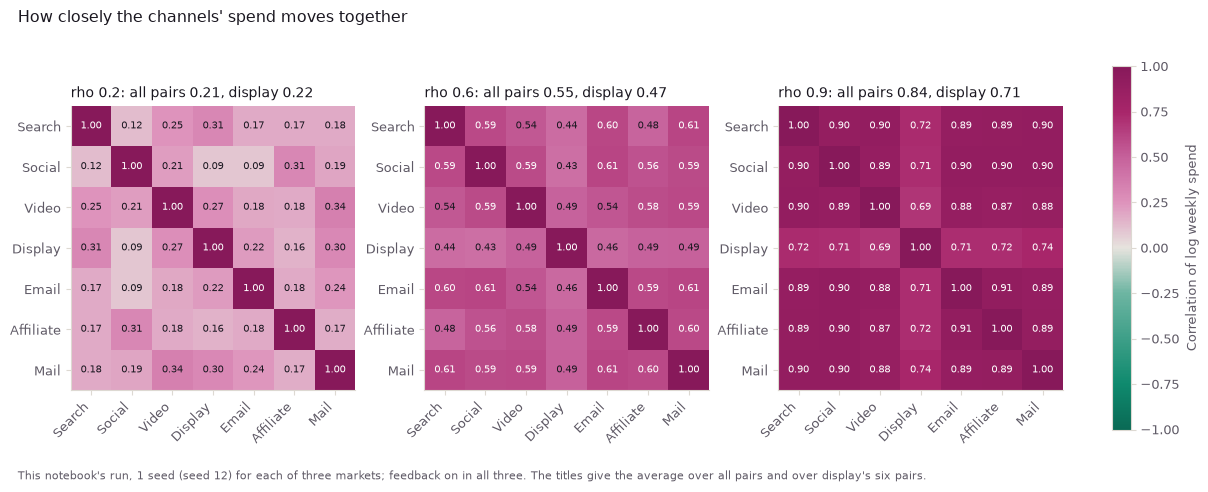

In [4]:
from matplotlib.colors import LinearSegmentedColormap

SHORT = {
    "paid_search": "Search", "paid_social": "Social", "online_video": "Video", "display_retargeting": "Display",
    "email": "Email", "affiliate_promo": "Affiliate", "direct_mail": "Mail",
}
diverging = LinearSegmentedColormap.from_list("diverging", PALETTE["diverging"])
display_index = CHANNELS.index("display_retargeting")
fig, axes = plt.subplots(1, 3, figsize=(12, 4.6), layout="constrained")
for ax, rho in zip(axes, (0.2, 0.6, 0.9)):
    _, panel_rho, market_rho = simulate_market(spec.model_copy(update={"spend_correlation": rho}))
    logs = np.log(np.column_stack([panel_rho[f"spend_{c}"].to_numpy() for c in CHANNELS]))
    corr = np.corrcoef(logs, rowvar=False)
    image = ax.imshow(corr, cmap=diverging, vmin=-1, vmax=1)
    for i in range(len(CHANNELS)):
        for j in range(len(CHANNELS)):
            ax.text(j, i, f"{corr[i, j]:.2f}", ha="center", va="center", fontsize=7, color=RAISED if abs(corr[i, j]) > 0.55 else INK)
    ax.set_xticks(range(len(CHANNELS)), [SHORT[c] for c in CHANNELS], rotation=45, ha="right")
    ax.set_yticks(range(len(CHANNELS)), [SHORT[c] for c in CHANNELS])
    ax.grid(False)
    others = np.delete(corr[display_index], display_index)
    ax.set_title(f"rho {rho:.1f}: all pairs {market_rho.achieved_spend_correlation:.2f}, display {others.mean():.2f}")
fig.colorbar(image, ax=axes, shrink=0.85, label="Correlation of log weekly spend")
finish(
    fig,
    "How closely the channels' spend moves together",
    run(1, f" (seed {SEED}) for each of three markets; feedback on in all three. The titles give the average over all pairs and over display's six pairs"),
)

At rho 0.9 the channels rise and fall together. That is the hard case for a mix model: when every channel is up in the same weeks, the panel cannot say which of them moved sales. At rho 0.6 and 0.9, display and retargeting moves least with the others, because its spend also follows last week's demand rather than the plan alone; at rho 0.2 everything is loosely tied and it does not stand out. Following demand is the second switch, and it is the one that tempts a model to credit display with demand it did not cause.

## 3. Fitting `own` on the demonstration seed

`own` is the mix model written in this repository (`marginal_mmm.own`). Sales are organic demand, multiplicative in trend, price, promotion, holidays and seasonality, plus each channel's adstocked and saturated spend times a non negative ceiling. The carryover and the saturation are searched channel by channel: a grid on the in sample error first, then Nelder-Mead on the rolling origin validation error plus the in sample error plus a small shape penalty. The intervals come from a moving block bootstrap over weeks. The full published spec fits in well under a minute, so I fit it as published and cut nothing.

In [5]:
from marginal_evaluation import observed
from marginal_mmm import MMMSpec, fit

own_spec = MMMSpec(backend="own", seed=SEED)
started = time.perf_counter()
model = fit(observed(national), own_spec)
print(f"Fit in {time.perf_counter() - started:.0f} seconds; spec hash {model.spec_hash}.")
print("The published demonstration fit:", published("mmm.own.spec_hash"))
print()

estimates = model.intervals()
covered = [e.roas_lower <= TRUTH[e.channel]["roas_true"] <= e.roas_upper for e in estimates]
show(
    ["Channel", "Return", "Lower", "Upper", "Truth", "Covers", "Marginal return", "True marginal"],
    [
        [
            CHANNEL_LABELS[e.channel],
            f"{e.roas:.2f}",
            f"{e.roas_lower:.2f}",
            f"{e.roas_upper:.2f}",
            f"{TRUTH[e.channel]['roas_true']:.2f}",
            "yes" if hit else "no",
            f"{e.marginal_return:.2f}",
            f"{TRUTH[e.channel]['marginal_return_true']:.2f}",
        ]
        for e, hit in zip(estimates, covered)
    ],
    run(1, f" (seed {SEED}); {own_spec.level:.0%} block bootstrap intervals, {own_spec.bootstrap_replicates} replicates. The interval covers the truth in {sum(covered)} of {len(covered)} channels"),
)

Fit in 12 seconds; spec hash 0c07159692e406de.
The published demonstration fit: 0c07159692e406de  [Source: simulated, model own, demonstration brand, 156 weeks, condition rho 0.6, feedback on, seed 12, as of 2026-09-27.]

Channel                    Return  Lower  Upper  Truth  Covers  Marginal return  True marginal
-------------------------  ------  -----  -----  -----  ------  ---------------  -------------
Paid search                  2.38   2.24   2.61   3.15      no             2.17           2.35
Paid social                  3.02   2.58   3.38   2.37      no             2.67           2.33
Online video                 0.85   0.36   1.19   1.59      no             1.02           1.43
Display and retargeting      1.62   1.18   1.92   1.22     yes             0.76           0.69
Email                        4.79   3.21   6.79   7.70      no             3.93           4.06
Affiliate and promo codes    1.60   1.27   2.00   2.74      no             1.83           2.36
Direct mail       

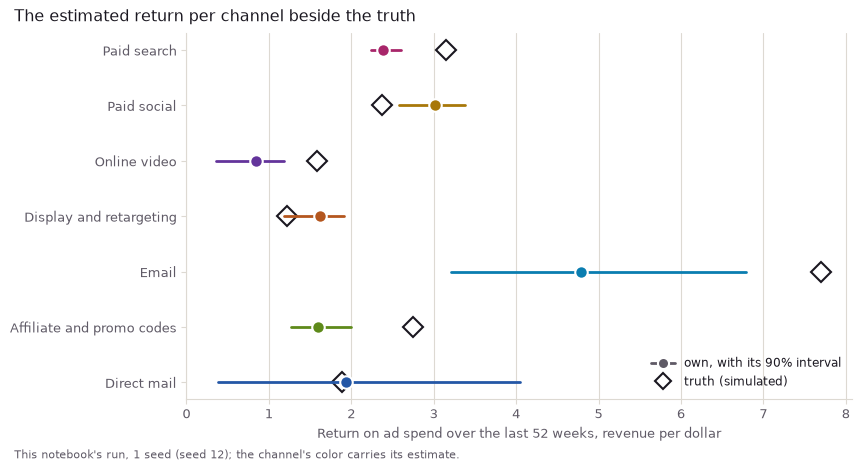

In [6]:
from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=(8.5, 4.4), layout="constrained")
rows = np.arange(len(estimates))[::-1]
for y, e in zip(rows, estimates):
    ax.plot(TRUTH[e.channel]["roas_true"], y, "D", ms=10, mfc="none", mec=INK, mew=1.5)
    ax.plot([e.roas_lower, e.roas_upper], [y, y], color=COLOR[e.channel], lw=2)
    ax.plot(e.roas, y, "o", ms=9, color=COLOR[e.channel], mec=RAISED, mew=1.5)
ax.set_yticks(rows, [CHANNEL_LABELS[e.channel] for e in estimates])
ax.grid(axis="y", visible=False)
ax.set_xlim(left=0)
ax.set_xlabel("Return on ad spend over the last 52 weeks, revenue per dollar")
ax.legend(
    handles=[
        Line2D([], [], color=INK2, lw=2, marker="o", ms=8, mec=RAISED, mew=1.5, label=f"own, with its {own_spec.level:.0%} interval"),
        Line2D([], [], ls="none", marker="D", ms=8, mfc="none", mec=INK, mew=1.5, label="truth (simulated)"),
    ],
    loc="lower right",
)
finish(fig, "The estimated return per channel beside the truth", run(1, f" (seed {SEED}); the channel's color carries its estimate"))

The model gets the broad picture: email earns the most per dollar and online video close to the least, as in the truth. It gets the detail wrong in both directions. Online video, email and affiliate and promo codes come out well below their truth; paid social and display and retargeting come out above it, display in the direction feedback pushes it. The intervals cover the truth in only two of the seven channels. They are too narrow for a stated reason: the bootstrap holds the searched carryover and saturation fixed, so it carries the noise in the ceilings and none of the uncertainty in the shapes. One seed shows the pattern; the recovery study in section 5 measures it.

## 4. The dead end, kept: the transform search that overfit the validation origins

The first version of this search chose each channel's carryover and saturation on the rolling origin validation error (fit on the weeks before an origin, forecast the next thirteen, repeat at eight origins), and the saturation curve was allowed to go anywhere. It credited one channel with a return of about seventy six to one, because a curve that can go anywhere can bend itself to the noise in eight validation windows, and the forecast error hardly moves when it does.

The fix was five changes, all still in `marginal_mmm.own`:

- a non negative intercept, so the baseline cannot go below zero and hand its sales to a channel;
- a log linear baseline with additive media: organic demand is multiplicative in its drivers, and media adds to it;
- bounded transforms, so carryover, half saturation and slope stay inside a stated box;
- an in sample grid before Nelder-Mead, so the search starts from a shape the whole panel supports;
- a small shape penalty toward the shapes marketing responses have, added to an objective that also carries the in sample error.

The first version never reached a commit, so I cannot rerun it as it was. What I can rerun is the failure in its plainest form. For each channel in turn I hold the other six at the final fit's transforms, let this channel's curve go anywhere (carryover up to 0.99, any half saturation, any slope) and score it on the rolling origin error alone, with the backend's own solver and objective. Then I read off the carryover it picks and the return the in sample solve gives, beside the final objective's and the truth.

In [7]:
import math

from marginal_mmm import design_columns
from marginal_mmm.own import SCALE, ChannelParams, Solver, _objective, _saturate, _unpack_one
from scipy.optimize import minimize

low, high = _unpack_one(np.full(3, -30.0), 1.0), _unpack_one(np.full(3, 30.0), 1.0)
print(
    "The final search's box, read from marginal_mmm.own: carryover up to "
    f"{high.theta:.1f}, half saturation {low.k:.1f} to {high.k:.1f} times mean spend, slope {low.s:.1f} to {high.s:.1f}."
)

panel = observed(national).sort("week")
spend = np.column_stack([panel[f"spend_{c}"].to_numpy() for c in CHANNELS])
controls, names = design_columns(panel, own_spec)
solver = Solver(panel["sales"].to_numpy(), controls, np.array([n.startswith(("sin", "cos")) for n in names]))
mean_spend = spend.mean(axis=0)
last_year = slice(len(panel) - own_spec.last_year_weeks, len(panel))
# The rolling origin error alone: the backend's objective with the in sample term weighted to nothing.
VALIDATION_ONLY = own_spec.model_copy(update={"validation_weight": 1e6, "shape_penalty": 0.0})


def rolling_error(transforms):
    saturated = _saturate(spend, transforms, own_spec.adstock_max_lag)
    return _objective(solver, saturated, model.ridge, VALIDATION_ONLY, None) / VALIDATION_ONLY.validation_weight


def returns(transforms):
    saturated = _saturate(spend, transforms, own_spec.adstock_max_lag)
    ceilings = solver.solve(saturated, model.ridge).beta * SCALE
    return ceilings * saturated[last_year].sum(axis=0) / spend[last_year].sum(axis=0)


def anywhere(v, j):
    # Coordinates on the whole real line to a curve that may go anywhere.
    return ChannelParams(theta=0.99 / (1.0 + math.exp(-v[0])), k=float(mean_spend[j] * math.exp(v[1])), s=math.exp(v[2]))


def coordinates(p, j):
    share = min(max(p.theta / 0.99, 1e-6), 1.0 - 1e-6)
    return np.array([math.log(share / (1.0 - share)), math.log(p.k / mean_spend[j]), math.log(p.s)])


final = list(model.params)
final_error = rolling_error(final)
final_returns = returns(final)
started = time.perf_counter()
search = []
for j, channel in enumerate(CHANNELS):
    def validation_alone(v, j=j):
        trial = list(final)
        trial[j] = anywhere(v, j)
        return rolling_error(trial)

    found = minimize(validation_alone, coordinates(final[j], j), method="Nelder-Mead", options={"maxfev": 200, "xatol": 1e-4, "fatol": 1e-9})
    chosen = list(final)
    chosen[j] = anywhere(found.x, j)
    search.append(
        {
            "channel": channel,
            "free": chosen[j],
            "error_change": rolling_error(chosen) / final_error - 1.0,
            "free_return": returns(chosen)[j],
            "final_return": final_returns[j],
        }
    )
print(f"Seven searches in {time.perf_counter() - started:.0f} seconds.")

The final search's box, read from marginal_mmm.own: carryover up to 0.9, half saturation 0.3 to 4.0 times mean spend, slope 0.8 to 2.5.


Seven searches in 12 seconds.


In [8]:
note = run(1, f" (seed {SEED}); one channel searched at a time, the other six held at the final fit")
show(
    ["Channel", "Carryover, true", "final", "validation only", "Slope, true", "final", "validation only", "Half saturation / mean spend, validation only"],
    [
        [
            CHANNEL_LABELS[r["channel"]],
            f"{TRUTH[r['channel']]['carryover']:.2f}",
            f"{model.params[j].theta:.2f}",
            f"{r['free'].theta:.2f}",
            f"{TRUTH[r['channel']]['slope']:.1f}",
            f"{model.params[j].s:.1f}",
            f"{r['free'].s:.1f}",
            f"{r['free'].k / mean_spend[j]:.2f}",
        ]
        for j, r in enumerate(search)
    ],
    note,
)
print()
show(
    ["Channel", "Return, true", "final", "validation only", "Rolling origin error vs final"],
    [
        [
            CHANNEL_LABELS[r["channel"]],
            f"{TRUTH[r['channel']]['roas_true']:.2f}",
            f"{r['final_return']:.2f}",
            f"{r['free_return']:.2f}",
            f"{r['error_change']:+.2%}",
        ]
        for r in search
    ],
    note,
)
biggest = max(search, key=lambda r: abs(r["free_return"] / r["final_return"] - 1.0))
further = sum(
    abs(r["free_return"] - TRUTH[r["channel"]]["roas_true"]) > abs(r["final_return"] - TRUTH[r["channel"]]["roas_true"])
    for r in search
)
print()
print(
    f"The validation only search changed the rolling origin error by at most {max(abs(r['error_change']) for r in search):.2%}. "
    f"It moved {CHANNEL_LABELS[biggest['channel']].lower()}'s return from {biggest['final_return']:.2f} to {biggest['free_return']:.2f} "
    f"(truth {TRUTH[biggest['channel']]['roas_true']:.2f}), and it left the return further from the truth than the final fit "
    f"in {further} of {len(search)} channels. {note}"
)

Channel                    Carryover, true  final  validation only  Slope, true  final  validation only  Half saturation / mean spend, validation only
-------------------------  ---------------  -----  ---------------  -----------  -----  ---------------  ---------------------------------------------
Paid search                           0.20   0.18             0.17          1.6    1.6              2.0                                           1.06
Paid social                           0.35   0.43             0.42          1.8    1.6              3.8                                           0.89
Online video                          0.65   0.29             0.15          1.5    1.8              2.6                                           1.39
Display and retargeting               0.30   0.21             0.22          2.2    1.6              2.7                                           0.66
Email                                 0.15   0.09             0.00          2.4    1.7        

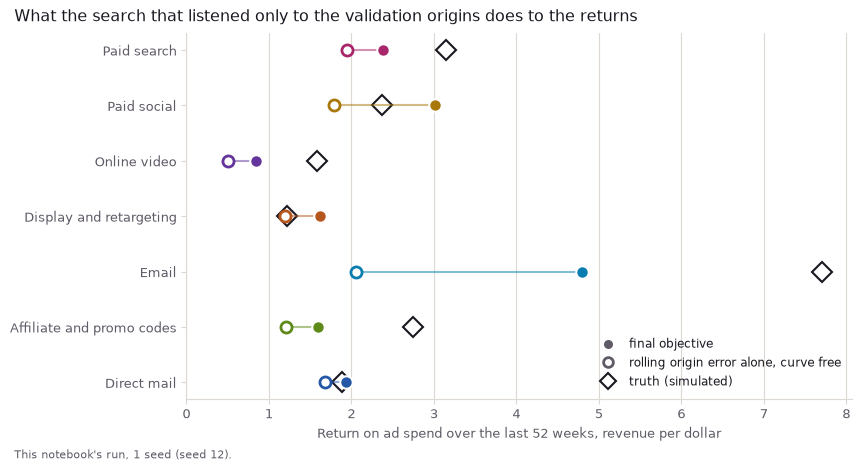

In [9]:
fig, ax = plt.subplots(figsize=(8.5, 4.4), layout="constrained")
rows = np.arange(len(search))[::-1]
for y, r in zip(rows, search):
    color = COLOR[r["channel"]]
    ax.plot(TRUTH[r["channel"]]["roas_true"], y, "D", ms=10, mfc="none", mec=INK, mew=1.5)
    ax.plot([r["final_return"], r["free_return"]], [y, y], color=color, lw=1.5, alpha=0.5)
    ax.plot(r["final_return"], y, "o", ms=9, color=color, mec=RAISED, mew=1.5)
    ax.plot(r["free_return"], y, "o", ms=8, mfc=RAISED, mec=color, mew=2)
ax.set_yticks(rows, [CHANNEL_LABELS[r["channel"]] for r in search])
ax.grid(axis="y", visible=False)
ax.set_xlim(left=0)
ax.set_xlabel("Return on ad spend over the last 52 weeks, revenue per dollar")
ax.legend(
    handles=[
        Line2D([], [], ls="none", marker="o", ms=8, color=INK2, mec=RAISED, mew=1.5, label="final objective"),
        Line2D([], [], ls="none", marker="o", ms=7, mfc=RAISED, mec=INK2, mew=2, label="rolling origin error alone, curve free"),
        Line2D([], [], ls="none", marker="D", ms=8, mfc="none", mec=INK, mew=1.5, label="truth (simulated)"),
    ],
    loc="lower right",
)
finish(fig, "What the search that listened only to the validation origins does to the returns", run(1, f" (seed {SEED})"))

This is the dead end in a milder form. With the other fixes in place, the free search did not produce anything like seventy six to one in this run: a non negative ceiling and a multiplicative baseline leave a curve less room to run. The mechanism is still visible, though. The search that listened only to the validation origins changed their error by about one percent at most, and for that it moved several returns a long way, mostly away from the truth, while several of the slopes it chose ran past the steepest in the truth table. The rolling origin error is nearly flat across very different shapes, so on its own it cannot choose between them, and whatever it picks, it picks on the noise in eight windows of thirteen weeks.

What holds the shape in the final objective is the in sample error, which ties it to all 156 weeks, and the shape penalty, which settles what the data cannot. That penalty is a stated choice in `MMMSpec`, not a discovery, and the bayes backend makes the same choice with its priors. I would rather state it than let the noise make it.

## 5. A tiny recovery study

The published recovery study refits `own` on markets the simulator draws fresh, twenty seeds in each of six conditions, and grades every channel's return against the truth: the error, whether the interval covers the truth, and whether the ranking of channels by marginal return agrees with the true ranking, which is what the optimizer needs. Here is the same runner, `run_recovery`, on three seeds in two conditions at the two ends of the design: the least correlated spend with no feedback (rho 0.2, feedback off) and the most correlated with feedback (rho 0.9, feedback on).

The seeds are the first three the published study used, and the fit is the published spec, so the rows should match the committed ones exactly. This is the slow cell: six full fits.

In [10]:
from marginal_evaluation import ChannelEstimate, FitResult, run_recovery, summarise


def fit_own(panel, seed):
    # The published recovery fit: own at the published spec, reported the way the runner grades it.
    fitted = fit(panel, MMMSpec(backend="own", seed=seed))
    channels = [
        ChannelEstimate(
            channel=e.channel, roas=e.roas, roas_lower=e.roas_lower, roas_upper=e.roas_upper,
            marginal_return=e.marginal_return, carryover=e.carryover,
        )
        for e in fitted.intervals()
    ]
    return FitResult(backend="own", channels=channels, diagnostics=fitted.diagnostics())


TINY = [(0.2, False), (0.9, True)]
FIRST_SEED = 1000
LABEL = run(3, f" per condition (seeds {FIRST_SEED} to {FIRST_SEED + 2})")
started = time.perf_counter()
rows, ranks, diagnostics = run_recovery(fit_own, "own", TINY, seeds=3, first_seed=FIRST_SEED)
print(f"{len(diagnostics)} fits in {time.perf_counter() - started:.0f} seconds.")

committed = pl.read_parquet(paths().results / "recovery" / "own_rows.parquet")
matched = rows.join(committed, on=["condition", "seed", "channel"], suffix="_committed")
largest = float((matched["roas_estimate"] - matched["roas_estimate_committed"]).abs().max())
print(f"{matched.height} of {rows.height} rows found in the committed study; the largest difference in a return estimate is {largest:.2g}. {LABEL}")

6 fits in 111 seconds.
42 of 42 rows found in the committed study; the largest difference in a return estimate is 0. This notebook's run, 3 seeds per condition (seeds 1000 to 1002).


In [11]:
summary = summarise(rows, ranks, level=POLICY.interval_level, seed=SEED)
overall = summary.filter(pl.col("channel") == "all")
show(
    ["Condition", "Median absolute error", f"Coverage (nominal {POLICY.interval_level:.0%})", "Rank agreement", "Lower", "Upper"],
    [
        [
            r["condition"],
            format_value(r["median_abs_error"], "pct1"),
            format_value(r["coverage"], "pct0"),
            f"{r['rank_agreement']:.2f}",
            f"{r['rank_agreement_lower']:.2f}",
            f"{r['rank_agreement_upper']:.2f}",
        ]
        for r in overall.iter_rows(named=True)
    ],
    LABEL + " The rank agreement interval is a bootstrap over the three seeds.",
)

Condition              Median absolute error  Coverage (nominal 90%)  Rank agreement  Lower  Upper
---------------------  ---------------------  ----------------------  --------------  -----  -----
rho 0.2, feedback off                  56.2%                     19%            0.54   0.25   0.82
rho 0.9, feedback on                   40.9%                     62%            0.42   0.23   0.61
This notebook's run, 3 seeds per condition (seeds 1000 to 1002). The rank agreement interval is a bootstrap over the three seeds.


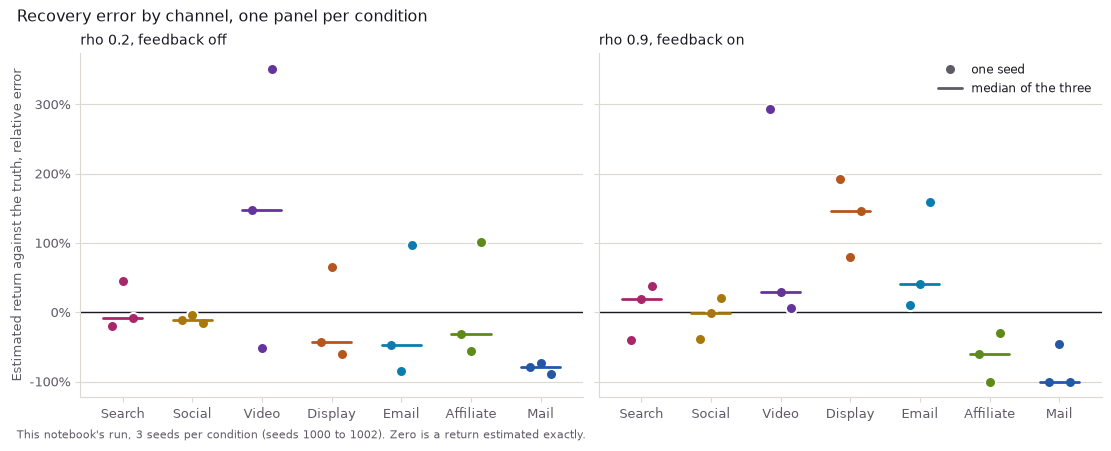

In [12]:
conditions = overall["condition"].to_list()
fig, axes = plt.subplots(1, len(conditions), figsize=(11, 4.2), sharey=True, layout="constrained")
for ax, condition in zip(axes, conditions):
    part = rows.filter(pl.col("condition") == condition)
    ax.axhline(0.0, color=INK, lw=1)
    for x, channel in enumerate(CHANNELS):
        errors = part.filter(pl.col("channel") == channel).sort("seed")["relative_error"].to_numpy()
        ax.plot(x + np.array([-0.15, 0.0, 0.15])[: len(errors)], errors, "o", ms=8, color=COLOR[channel], mec=RAISED, mew=1.5)
        ax.plot([x - 0.28, x + 0.28], [np.median(errors)] * 2, color=COLOR[channel], lw=2)
    ax.set_xticks(range(len(CHANNELS)), [SHORT[c] for c in CHANNELS])
    ax.grid(axis="x", visible=False)
    ax.set_title(condition)
    ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
axes[0].set_ylabel("Estimated return against the truth, relative error")
axes[-1].legend(
    handles=[
        Line2D([], [], ls="none", marker="o", ms=8, color=INK2, mec=RAISED, mew=1.5, label="one seed"),
        Line2D([], [], color=INK2, lw=2, label="median of the three"),
    ],
    loc="upper right",
)
finish(fig, "Recovery error by channel, one panel per condition", LABEL + " Zero is a return estimated exactly.")

The published study is the one the pages quote. It has twenty seeds per condition for `own` and three for `bayes` (a posterior fit takes minutes, not seconds), in all six conditions. I read its figures from the manifest rather than retype them, each with its provenance.

In [13]:
for backend in ("own", "bayes"):
    print(f"Published recovery study, {backend}:")
    for key, what in [
        ("seeds_per_condition", "seeds per condition"),
        ("conditions", "conditions"),
        ("fits_that_ran", "fits that ran"),
        ("median_abs_error_overall", "median absolute error, every condition"),
        ("coverage_overall", f"interval coverage, every condition (nominal {POLICY.interval_level:.0%})"),
        ("rho_02_feedback_off.median_abs_error", "median absolute error, rho 0.2, feedback off"),
        ("rho_09_feedback_on.median_abs_error", "median absolute error, rho 0.9, feedback on"),
        ("rho_02_feedback_off.rank_agreement", "rank agreement, rho 0.2, feedback off"),
        ("rho_09_feedback_on.rank_agreement", "rank agreement, rho 0.9, feedback on"),
        ("error_floor", "the stated floor for the median absolute error"),
        ("conditions_over_floor", "conditions over that floor"),
    ]:
        print(f"  {what}: {published(f'recovery.{backend}.{key}')}")
    print()

mine = {r["condition"]: r["median_abs_error"] for r in overall.iter_rows(named=True)}
theirs = {
    "rho 0.2, feedback off": manifest.raw("recovery.own.rho_02_feedback_off.median_abs_error"),
    "rho 0.9, feedback on": manifest.raw("recovery.own.rho_09_feedback_on.median_abs_error"),
}
easy, hard = "rho 0.2, feedback off", "rho 0.9, feedback on"
print(
    f"On this notebook's three seeds per condition the median absolute error is {'higher' if mine[easy] > mine[hard] else 'lower'} "
    f"under {easy} than under {hard}. On the published study's {manifest.text('recovery.own.seeds_per_condition')} seeds "
    f"per condition it is {'higher' if theirs[easy] > theirs[hard] else 'lower'}."
)

Published recovery study, own:
  seeds per condition: 20  [Source: simulated, model own, markets with known truth, 20 seeds, as of 2026-09-27.]
  conditions: 6  [Source: simulated, model own, markets with known truth, 20 seeds, as of 2026-09-27.]
  fits that ran: 120  [Source: simulated, model own, markets with known truth, 20 seeds, as of 2026-09-27.]
  median absolute error, every condition: 37.1%  [Source: simulated, model own, markets with known truth, 20 seeds, as of 2026-09-27.]
  interval coverage, every condition (nominal 90%): 42%  [Source: simulated, model own, markets with known truth, 20 seeds, as of 2026-09-27.]
  median absolute error, rho 0.2, feedback off: 34.4%  [Source: simulated, model own, markets with known truth, condition rho 0.2, feedback off, 20 seeds, as of 2026-09-27.]
  median absolute error, rho 0.9, feedback on: 46.2%  [Source: simulated, model own, markets with known truth, condition rho 0.9, feedback on, 20 seeds, as of 2026-09-27.]
  rank agreement, rho

Three seeds show the machinery and the size of the errors: returns off by a third or more on a typical channel, and intervals that hold the truth far less often than their nominal ninety percent. They are not enough to rank conditions, and the printed line says whether this run happened to order the two conditions the way the published twenty seeds do. That is why the study the pages quote has twenty seeds for `own`, and why its intervals over seeds are printed beside every error. The findings it supports are printed above with their provenance: for `own`, the error is over the stated floor in every condition and the ranking of channels is less reliable where their spend moves most closely together. The model is graded on that before it gets near a budget.